In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns
#!pip install pmdarima
from pmdarima import auto_arima
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
import pmdarima as pmd

from statsmodels.tsa.statespace.sarimax import SARIMAX

Master_File= '/Users/kellyxu/Documents/Uni/Capstone/nsw_clean_outputs/Master_dataset-demand_temp_forecast.csv'
demand= pd.read_csv(Master_File)

In [13]:
demand['datetime'] = pd.to_datetime(demand['datetime'])
demand['date'] = demand['datetime'].dt.date
demanddaily = demand.groupby('date').mean(numeric_only=True)
demanddaily

,demand_mw,year,month,day,hour,minute,dow,is_weekend,roll_30min,roll_7d,roll_14d,roll_30d,temp_c,forecast_mw,horizon_steps,horizon_hours,halfhour,fcst_error,fcst_abs_error,fcst_ape
date,,,,,,,,,,,,,,,,,,,,
2010-01-01,7801.352917,2010.0,1.0,1.0,11.5,15.0,4.0,0.0,7801.352917,7332.099722,7332.099722,7332.099722,25.183333,7740.516458,0.0,0.475544,23.5,-60.836458,115.415208,1.518815
2010-01-02,8017.459792,2010.0,1.0,2.0,11.5,15.0,5.0,1.0,8017.459792,7720.159995,7720.159995,7720.159995,24.748958,7932.043958,0.0,0.475185,23.5,-85.415833,113.290417,1.437769
2010-01-03,7399.899583,2010.0,1.0,3.0,11.5,15.0,6.0,1.0,7399.899583,7756.144730,7756.144730,7756.144730,19.460590,7425.773542,0.0,0.476053,23.5,25.873958,63.698958,0.881358
2010-01-04,8241.720208,2010.0,1.0,4.0,11.5,15.0,0.0,0.0,8241.720208,7747.012890,7747.012890,7747.012890,20.842708,8318.683333,0.0,0.475723,23.5,76.963125,88.890625,1.075147
2010-01-05,8827.813125,2010.0,1.0,5.0,11.5,15.0,1.0,0.0,8827.813125,7911.775154,7911.775154,7911.775154,22.660417,8858.899792,0.0,0.475694,23.5,31.086667,83.637917,0.952121
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-14,7092.584375,2021.0,3.0,14.0,11.5,15.0,6.0,1.0,7092.584375,7596.827773,7458.399929,7443.967013,18.063889,NaN,NaN,NaN,23.5,NaN,NaN,NaN
2021-03-15,6930.622708,2021.0,3.0,15.0,11.5,15.0,0.0,0.0,6930.622708,7577.123957,7403.812269,7413.534146,17.116667,NaN,NaN,NaN,23.5,NaN,NaN,NaN
2021-03-16,7330.375208,2021.0,3.0,16.0,11.5,15.0,1.0,0.0,7330.375208,7496.472178,7324.849896,7425.633531,18.066146,NaN,NaN,NaN,23.5,NaN,NaN,NaN


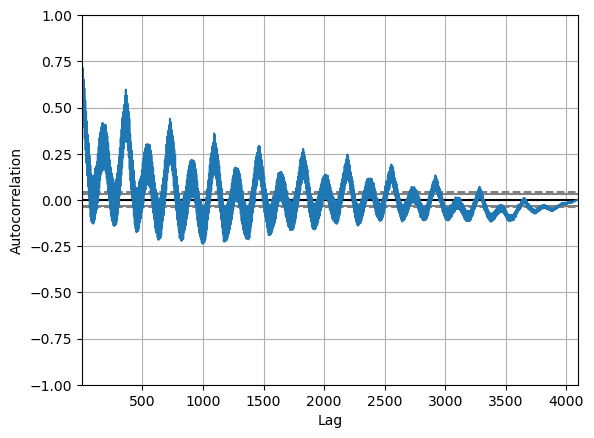

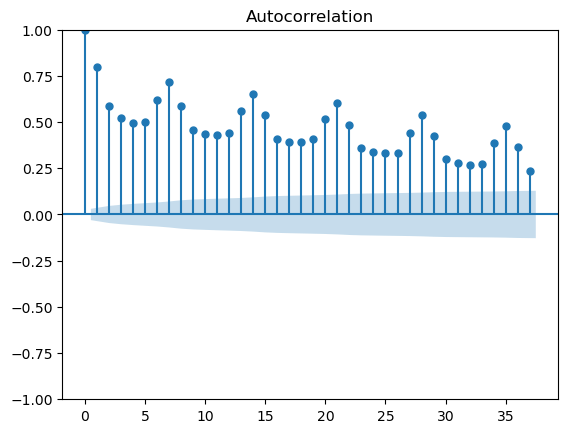

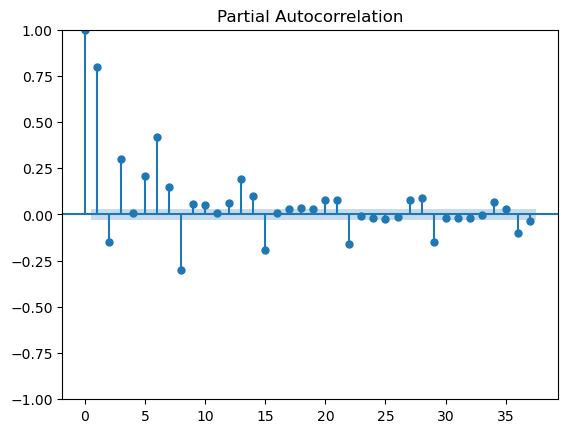

In [3]:
autocorrelation_plot(demanddaily['demand_mw'])

#ACF plots

plot_acf(demanddaily['demand_mw'])
plt.show()

plot_pacf(demanddaily['demand_mw'])
plt.show()

### Comments
**Autocorrelation Plot**

- Decreasing correlation (d=1)

**Autocorrelation Function**
- Multiples of 7, could suggest seasonal MA =1

**Partial Autocorrelation Function**

- p,P = 1 (AR)

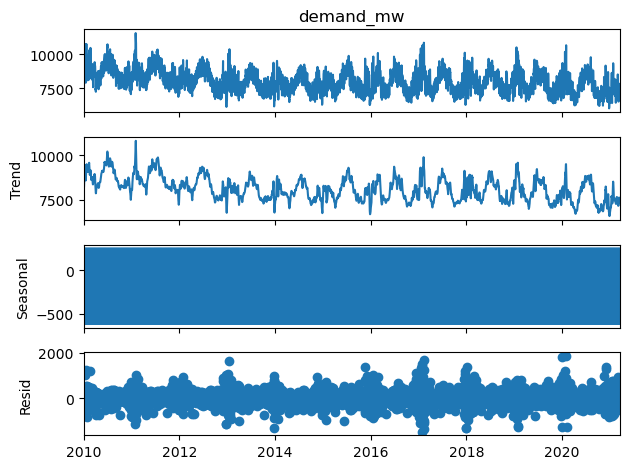

In [14]:
decomposition=seasonal_decompose(demanddaily['demand_mw'],model='additive',period=7)
decomposition.plot()
plt.show()

In [5]:
demand_diff = demanddaily['demand_mw'].diff(periods=7)

demand_diff = demand_diff.dropna()

dftest = adfuller(demand_diff, autolag='AIC')

print("1. ADF Statistic : ", dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags Used : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t", key, ": ", val)

1. ADF Statistic :  -11.127645417006676
2. P-Value :  3.342965713843763e-20
3. Num Of Lags Used :  30
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 4057
5. Critical Values :
	 1% :  -3.431962877092949
	 5% :  -2.862252680813649
	 10% :  -2.567149367114502


Diff. series is stationary. d=0 (non-seasonal differencing not required).  

In [6]:
import pmdarima as pmd
model=pmd.auto_arima(demanddaily['demand_mw'],start_p=1,start_q=1,test='adf',m=7,seasonal=True,trace=True)


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[7] intercept   : AIC=60711.003, Time=4.36 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=66354.050, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=60757.485, Time=1.97 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=62136.085, Time=1.02 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=85382.683, Time=0.03 sec
 ARIMA(1,0,1)(0,0,1)[7] intercept   : AIC=61172.133, Time=1.47 sec
 ARIMA(1,0,1)(1,0,0)[7] intercept   : AIC=60470.453, Time=3.68 sec
 ARIMA(1,0,1)(0,0,0)[7] intercept   : AIC=62011.812, Time=0.21 sec
 ARIMA(1,0,1)(2,0,0)[7] intercept   : AIC=60561.054, Time=8.14 sec
 ARIMA(1,0,1)(2,0,1)[7] intercept   : AIC=60737.642, Time=9.80 sec
 ARIMA(0,0,1)(1,0,0)[7] intercept   : AIC=63151.305, Time=1.56 sec
 ARIMA(2,0,1)(1,0,0)[7] intercept   : AIC=inf, Time=3.56 sec
 ARIMA(1,0,2)(1,0,0)[7] intercept   : AIC=61061.476, Time=3.55 sec
 ARIMA(0,0,0)(1,0,0)[7] intercept   : AIC=66335.580, Time=0.94 sec
 ARIMA(0,0,2)(1,0,0)[7] i

In [7]:
#Changed Q (seasonal MA to 1 as ACF graph showed multiples of 7)
sarima=SARIMAX(demanddaily['demand_mw'],order=(1,0,1),seasonal_order=(1,0,1,7))
predicted=sarima.fit().predict();predicted

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  7.45476D+00    |proj g|=  1.16682D-01


/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.



At iterate    5    f=  7.38658D+00    |proj g|=  8.10778D-03

At iterate   10    f=  7.38405D+00    |proj g|=  3.31175D-03

At iterate   15    f=  7.35860D+00    |proj g|=  1.76290D-02

At iterate   20    f=  7.24788D+00    |proj g|=  1.39345D-02

At iterate   25    f=  7.24131D+00    |proj g|=  3.20041D-03

At iterate   30    f=  7.23990D+00    |proj g|=  7.37500D-05

At iterate   35    f=  7.23989D+00    |proj g|=  7.82363D-04

At iterate   40    f=  7.23934D+00    |proj g|=  7.23209D-03

At iterate   45    f=  7.23795D+00    |proj g|=  8.41088D-04

At iterate   50    f=  7.23751D+00    |proj g|=  1.32254D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2010-01-01       0.000000
2010-01-02    7294.042748
2010-01-03    7516.951224
2010-01-04    7049.747889
2010-01-05    7885.625181
                 ...     
2021-03-14    7435.308402
2021-03-15    7726.590033
2021-03-16    7062.982536
2021-03-17    7367.727686
2021-03-18    7561.402186
Freq: D, Name: predicted_mean, Length: 4095, dtype: float64

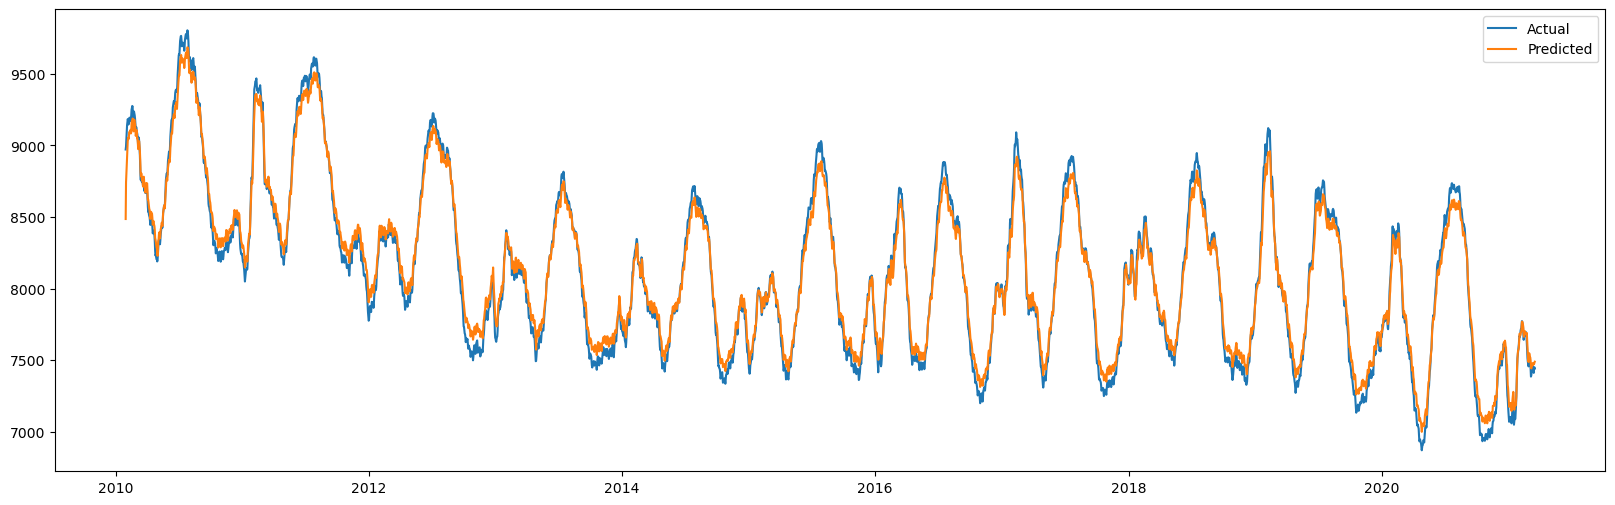

In [8]:
actual_smooth = demanddaily['demand_mw'].rolling(30).mean()
predicted_smooth = predicted.rolling(30).mean()


plt.figure(figsize=(20,6))
plt.plot(actual_smooth,label='Actual')
plt.plot(predicted_smooth,label='Predicted')
plt.legend()

In [16]:
resid = demanddaily['demand_mw'] - predicted
mae = resid.abs().mean()
print(mae)


rmse = np.sqrt((resid**2).mean())
print(rmse)

229.730873017463
358.9834131639044


In [10]:
exog = demanddaily['temp_c']
sarimax=SARIMAX(demanddaily['demand_mw'],order=(1,0,1),seasonal_order=(1,0,1,7),exog=exog)

predicted1 = sarimax.fit().predict(); predicted1

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            6     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.16633D+00    |proj g|=  1.36902D-01


/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
 This problem is unconstrained.



At iterate    5    f=  8.12366D+00    |proj g|=  2.04962D-02

At iterate   10    f=  8.11947D+00    |proj g|=  2.67194D-03

At iterate   15    f=  8.10790D+00    |proj g|=  7.42109D-03

At iterate   20    f=  7.92810D+00    |proj g|=  4.38752D-02

At iterate   25    f=  7.82889D+00    |proj g|=  4.46945D-03

At iterate   30    f=  7.65035D+00    |proj g|=  5.10694D-02

At iterate   35    f=  7.59887D+00    |proj g|=  2.30992D-02

At iterate   40    f=  7.57397D+00    |proj g|=  3.95440D-03

At iterate   45    f=  7.23389D+00    |proj g|=  1.12698D-01

At iterate   50    f=  7.20482D+00    |proj g|=  2.69267D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tn

/Users/kellyxu/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


2010-01-01    1593.262816
2010-01-02    7773.143093
2010-01-03    7656.841220
2010-01-04    7505.764952
2010-01-05    8275.713436
                 ...     
2021-03-14    7017.055272
2021-03-15    7748.134208
2021-03-16    7163.840198
2021-03-17    7385.530685
2021-03-18    7377.827482
Freq: D, Name: predicted_mean, Length: 4095, dtype: float64

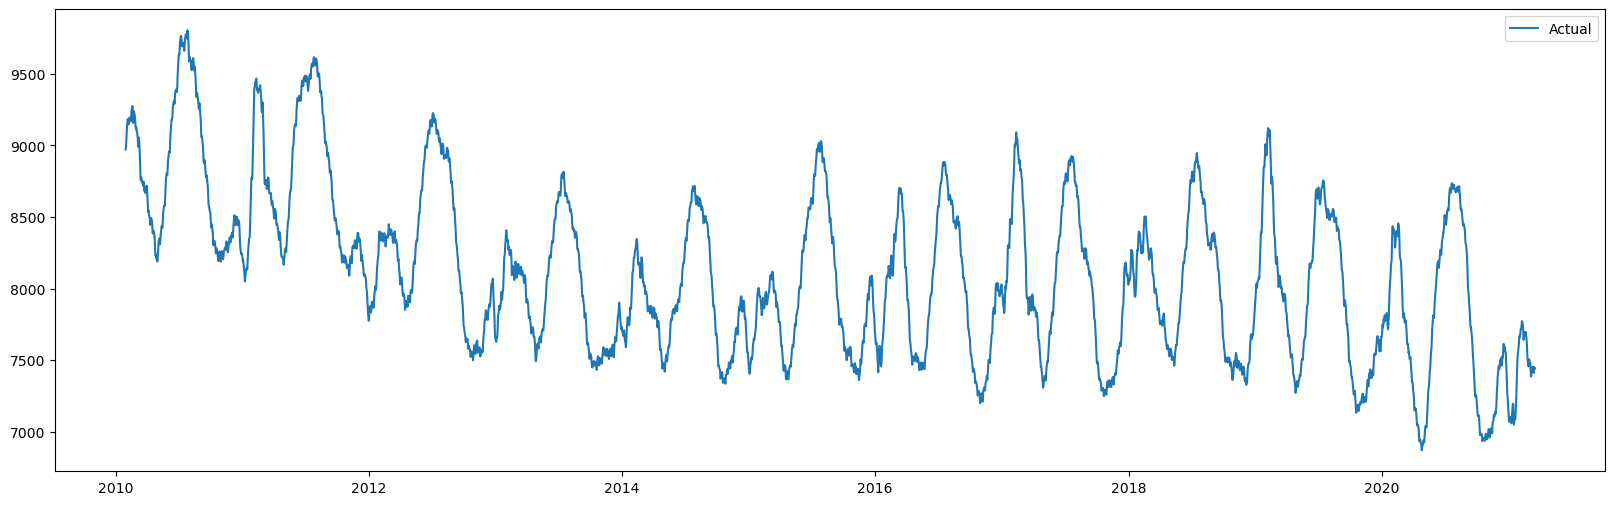

In [21]:
actual_smooth = demanddaily['demand_mw'].rolling(30).mean()
predicted_smooth = predicted1.rolling(30).mean()

plt.figure(figsize=(20,6))
plt.plot(actual_smooth,label='Actual')
plt.legend()

In [20]:
resid1 = demanddaily['demand_mw'] - predicted1
mae1 = resid1.abs().mean()
print(mae1)
rmse1 = np.sqrt((resid1**2).mean())
print(rmse1)

229.85393851680348
339.7105176568936
